# Phân tích và dự đoán lượt xem bài viết Vntrip

Tương tự `Chotot/Predict.ipynb`: làm sạch dữ liệu, EDA và Linear Regression. Biến mục tiêu là `view_count`, không phải đánh giá người dùng.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


In [6]:
project_root = Path.cwd()
if project_root.name == 'VNTRIP':
    project_root = project_root.parent
data_dir = project_root / 'data' / 'VNTRIP'

df = pd.read_csv(data_dir / 'rawdata.csv')
df.head()

,article_id,title,published_date,published_year,published_month,view_count,excerpt,article_text,source_url,image_url,collected_at
0,VNTRIP_e292c1570704,ATADI.VN – MỞ RA KỶ NGUYÊN DU LỊCH MỚI TRONG H...,2025-12-08,2025.0,12.0,1200.0,Du lịch hiện đại không còn dừng lại ở việc đặt...,0963 266 688 Đăng nhập Bảng điều khiển Đăng xu...,https://www.vntrip.vn/cam-nang/atadi-vn-mo-ra-...,https://cdn.vntrip.vn/cam-nang/wp-content/uplo...,2026-07-13T17:22:29.252519+00:00
1,VNTRIP_a5125a054e2d,Vntrip TMS – Giải pháp quản trị công tác và du...,2025-08-03,2025.0,8.0,806.0,Trong bối cảnh doanh nghiệp ngày càng mở rộng ...,0963 266 688 Đăng nhập Bảng điều khiển Đăng xu...,https://www.vntrip.vn/cam-nang/vntrip-tms-giai...,https://cdn.vntrip.vn/cam-nang/wp-content/uplo...,2026-07-13T17:22:32.303154+00:00
2,VNTRIP_b8e8fb9b5682,Chuyện chiếc bánh mì và bài học về sự tận tâm ...,2025-12-08,2025.0,12.0,627.0,"Trong kinh doanh, công nghệ có thể giúp tăng t...",0963 266 688 Đăng nhập Bảng điều khiển Đăng xu...,https://www.vntrip.vn/cam-nang/chuyen-chiec-ba...,https://cdn.vntrip.vn/cam-nang/wp-content/uplo...,2026-07-13T17:22:35.340877+00:00
3,VNTRIP_dfd03a4eb676,EMS – “Trợ lý tài chính AI” giúp doanh nghiệp ...,2025-12-01,2025.0,12.0,747.0,"EMS cắt giảm tối đa thời gian, loại bỏ thất th...",0963 266 688 Đăng nhập Bảng điều khiển Đăng xu...,https://www.vntrip.vn/cam-nang/ems-tro-ly-tai-...,https://cdn.vntrip.vn/cam-nang/wp-content/uplo...,2026-07-13T17:22:38.397746+00:00
4,VNTRIP_f79d32fc4eee,VNTRIP TMS – GIẢI PHÁP TỐI ƯU CHI PHÍ CÔNG TÁC...,2025-12-08,2025.0,12.0,606.0,NHỮNG CON SỐ BIẾT NÓI | GIẢI PHÁP TỐI ƯU CHI P...,0963 266 688 Đăng nhập Bảng điều khiển Đăng xu...,https://www.vntrip.vn/cam-nang/vntrip-tms-giai...,https://cdn.vntrip.vn/cam-nang/wp-content/uplo...,2026-07-13T17:22:41.436722+00:00


In [7]:
required_columns = {'article_id', 'title', 'excerpt', 'article_text', 'published_year', 'published_month', 'view_count'}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f'rawdata.csv thiếu cột: {sorted(missing_columns)}. Hãy chạy Export_Raw_Data.ipynb lại.')


In [8]:
frame = df.copy()
frame['published_date'] = pd.to_datetime(frame['published_date'], errors='coerce')
frame['view_count'] = pd.to_numeric(frame['view_count'], errors='coerce')
frame['published_year'] = pd.to_numeric(frame['published_year'], errors='coerce')
frame['published_month'] = pd.to_numeric(frame['published_month'], errors='coerce')
frame['title_length'] = frame['title'].fillna('').str.len()
frame['excerpt_length'] = frame['excerpt'].fillna('').str.len()
frame['article_length'] = frame['article_text'].fillna('').str.len()
dataset = frame.dropna(subset=['view_count', 'published_year', 'published_month']).copy()
dataset = dataset[['article_id', 'title_length', 'excerpt_length', 'article_length', 'published_year', 'published_month', 'view_count']]
dataset.to_csv(data_dir / 'dataset.csv', encoding='utf-8-sig', index=False)
dataset.head()

,article_id,title_length,excerpt_length,article_length,published_year,published_month,view_count
0,VNTRIP_e292c1570704,64,151,6890,2025.0,12.0,1200.0
1,VNTRIP_a5125a054e2d,87,152,7408,2025.0,8.0,806.0
2,VNTRIP_b8e8fb9b5682,89,154,7369,2025.0,12.0,627.0
3,VNTRIP_dfd03a4eb676,82,146,7335,2025.0,12.0,747.0
4,VNTRIP_f79d32fc4eee,63,152,4069,2025.0,12.0,606.0


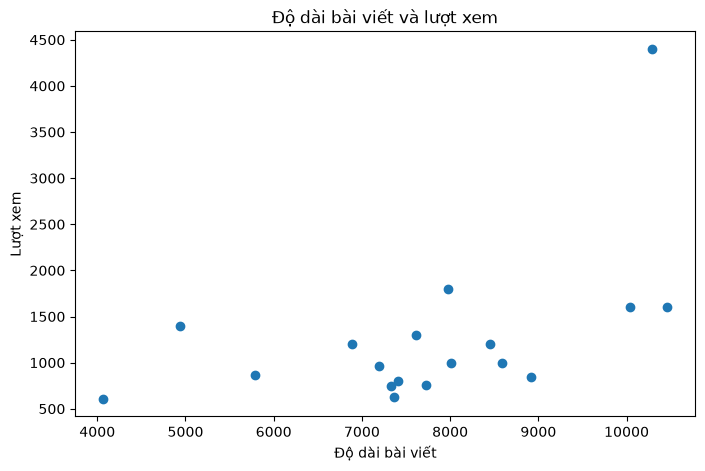

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(dataset['article_length'], dataset['view_count'])
plt.xlabel('Độ dài bài viết')
plt.ylabel('Lượt xem')
plt.title('Độ dài bài viết và lượt xem')
plt.show()

In [10]:
if len(dataset) < 10:
    raise ValueError('Cần tối thiểu 10 bài có ngày đăng và lượt xem để huấn luyện mô hình.')

features = ['title_length', 'excerpt_length', 'article_length', 'published_year', 'published_month']
X = dataset[features]
y = dataset['view_count']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=365)
reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', mean_squared_error(y_test, y_pred) ** 0.5)
print('R2:', r2_score(y_test, y_pred))

MAE: 140.49980530625953
RMSE: 189.34836632508745
R2: -0.8294405311840753
